In [1]:
import os
import csv
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from datetime import datetime

%matplotlib notebook
%matplotlib inline
mpl.use('Agg')  # Use non-interactive backend
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Computer Modern']
plt.rcParams['font.size'] = 20

laser_color = np.array([183, 86, 89])/255
laser_color_saturated = np.array([184,0,6])/255
mic_color = np.array([214, 174, 114])/255

In [2]:
def read_data(data_directory, file_name, downsampling=1):
    data = []
    time_axis = []
    timestamps = []
    i = 0
    first = True
    with open(os.path.join(data_directory, file_name), 'r', newline='') as csv_file:
        csv_reader = csv.reader(csv_file, delimiter=';')
        header = next(csv_reader)
        for row in csv_reader:
            timestamps.append(row[0])
            
            timestamp = datetime.strptime(row[0], '%Y-%m-%d %H:%M:%S.%f')
            if first:
                first_timestamp = timestamp
            if not first:
                time_axis += list(np.linspace((prev_timestamp - first_timestamp).total_seconds(),
                                              (timestamp - first_timestamp).total_seconds(), len(row) - 1, endpoint=False))
            i += 1
            data.append(np.array(row[1:]).astype('float'))
            prev_timestamp = timestamp
            first = False
        print(i)
    print(header)
    data = np.array(data[:-1]).reshape((1, np.size(data[:-1]))).flatten()  # reject last data row because no timestamps are estimated for it
    print(f'Original data shape: {data.shape}')
    data_downsampled = data[::downsampling]
    print(f'Downsampled data shape: {data_downsampled.shape}')
    return data_downsampled, header, timestamps, time_axis

In [3]:
def get_time_data(data, fs, view_range, x_time=True):
    time_axis_offset = 0
    if view_range:
        data = data[view_range[0]:view_range[1]]
    else:
        view_range = (0, data.size)
        print(f'No view range passed, using {view_range}')
    data_ac = data - np.mean(data)

    if x_time:
        time_axis = [(view_range[0] + i) / fs for i in range(len(data))]
        return time_axis, data
    else:
        time_axis = [view_range[0] + i for i in range(len(data))]
        return time_axis, data
    
def plot_data(data, fs, view_range, x_time=True):
    time_axis, data = get_time_data(data, fs, view_range, x_time=True)
    plt.plot(time_axis, data)
    if x_time:
        plt.xlabel("time [s]")
    else:
        plt.xlabel("sample")
    plt.ylabel("[V]")

In [4]:
def get_fft_data(data, fs, fft_range, view_range):
    if fft_range:
        fft_range[1] = min(fft_range[1], len(data))
        data = data[fft_range[0]:fft_range[1]]
    data_ac = data - np.mean(data)
    # print(f'data size: {data_ac.shape}')
    data_fft = np.abs(np.fft.fft(data_ac))
    # print(f'fft size: {data_fft.shape}')

    num_samples = data_fft.size
    if view_range:
        data_fft = data_fft[round(view_range[0] / fs * num_samples):
                            round(min(view_range[1], fs) / fs * num_samples)]
        freq = np.linspace(view_range[0], min(view_range[1], fs), data_fft.size)
        return freq, data_fft
    else:
        freq = np.linspace(0, fs, data_fft.size)
        return freq, data_fft
    
def plot_fft(data, fs, fft_range, view_range):
    freq, data_fft = get_fft_data(data, fs, fft_range, view_range)
    plt.plot(freq, data_fft)
    plt.xlabel("f [Hz]")
    plt.ylabel("FFT")

In [5]:
def parse_sensor_data(data_directory, laser_file_name, mic_file_name, 
                      downsampling, mic_signal_range, laser_signal_range, 
                      mic_rest_range, laser_rest_range, time_axis_offset=0):
    mic_data, mic_header, mic_timestamps, mic_time_axis = read_data(data_directory, mic_file_name, downsampling)
    mic_time_axis = np.array(mic_time_axis) - time_axis_offset
    mic_start_timestamp = datetime.strptime(mic_timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
    time1 = datetime.strptime(mic_timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
    time2 = datetime.strptime(mic_timestamps[-1], '%Y-%m-%d %H:%M:%S.%f')
    mic_time_difference = (time2 - time1).total_seconds()
    mic_fs = len(mic_data)/mic_time_difference / downsampling
    print(f'fs: {mic_fs}')

    mic_data = mic_data - np.mean(mic_data)
    mic_rest_power = np.sum((np.array(mic_data[mic_rest_range[0]:mic_rest_range[1]]) - np.mean(mic_data[mic_rest_range[0]:mic_rest_range[1]]))**2)/len(list(mic_data[mic_rest_range[0]:mic_rest_range[1]]))
    mic_slip_power = np.sum((np.array(mic_data[mic_signal_range[0]:mic_signal_range[1]]) - np.mean(mic_data[mic_signal_range[0]:mic_signal_range[1]]))**2)/len(list(mic_data[mic_signal_range[0]:mic_signal_range[1]]))
    mic_sensitivity = np.sqrt(mic_slip_power/mic_rest_power)
    print(f'MIC rest_power: {mic_rest_power} ; slip_power: {mic_slip_power} ; sensitivity: {mic_sensitivity}')


    laser_data, laser_header, laser_timestamps, laser_time_axis = read_data(data_directory, laser_file_name, downsampling)
    laser_start_timestamp = datetime.strptime(laser_timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
    laser_time_axis = np.array(laser_time_axis) + (laser_start_timestamp - mic_start_timestamp).total_seconds() - time_axis_offset
    time1 = datetime.strptime(laser_timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
    time2 = datetime.strptime(laser_timestamps[-1], '%Y-%m-%d %H:%M:%S.%f')
    laser_time_difference = (time2 - time1).total_seconds()
    laser_fs = len(laser_data)/laser_time_difference / downsampling
    print(f'fs: {laser_fs}')

    laser_data = np.array(laser_data - np.mean(laser_data))
    laser_rest_power = np.sum((laser_data[laser_rest_range[0]:laser_rest_range[1]] - np.mean(laser_data[laser_rest_range[0]:laser_rest_range[1]]))**2)/len(list(laser_data[laser_rest_range[0]:laser_rest_range[1]]))
    laser_slip_power = np.sum((laser_data[laser_signal_range[0]:laser_signal_range[1]] - np.mean(laser_data[laser_signal_range[0]:laser_signal_range[1]]))**2)/len(list(laser_data[laser_signal_range[0]:laser_signal_range[1]]))
    laser_sensitivity = np.sqrt(laser_slip_power/laser_rest_power)
    print(f'LASER rest_power: {laser_rest_power} ; slip_power: {laser_slip_power} ; sensitivity: {laser_sensitivity}')

    print(f'-------------- Laser is {laser_sensitivity/mic_sensitivity} times more sensitive than mic')
    
    return laser_data, laser_time_axis, laser_rest_power, mic_data, mic_time_axis, mic_rest_power

# Motor

<IPython.core.display.Javascript object>


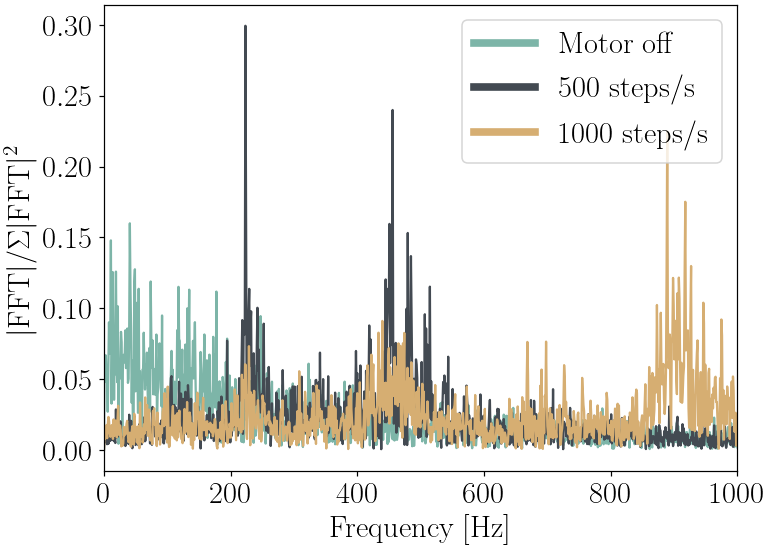

240
['fs 3700', 'frames_per_buffer None', 'samples_per_frame None', 'refresh_rate_hz None']
Original data shape: (23900,)
Downsampled data shape: (23900,)
240
['fs 3700', 'frames_per_buffer None', 'samples_per_frame None', 'refresh_rate_hz None']
Original data shape: (23900,)
Downsampled data shape: (23900,)
205
['fs 3700', 'frames_per_buffer None', 'samples_per_frame None', 'refresh_rate_hz None']
Original data shape: (20400,)
Downsampled data shape: (20400,)


In [6]:
%matplotlib notebook
from matplotlib.widgets import Button, Slider

downsampling = 1
data_directory = os.path.join(os.getcwd(), "motor")

file_names = ['motor_500_v2.csv', 'motor_500_v2.csv', 'motor_1000_v2.csv']
fft_ranges = [[323, 3249], [5653, 8580], [6282, 9111]]
colors = [np.array([0, 181, 139])/255, np.array([184,0,6])/255, np.array([64, 144, 214])/255, np.array([125, 181, 168])/255]
colors = [np.array([125, 181, 168])/255, np.array([67, 74, 82])/255, np.array([214, 174, 114])/255]

all_fft_data = {}

fig = plt.figure(figsize=(7, 5), constrained_layout=True)
plt.axvline(-10, linewidth=5, color=colors[0])
plt.axvline(-10, linewidth=5, color=colors[1])
plt.axvline(-10, linewidth=5, color=colors[2])
for i, file_name in enumerate(file_names):
    data, header, timestamps, _ = read_data(data_directory, file_name, downsampling)
    time1 = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
    time2 = datetime.strptime(timestamps[-1], '%Y-%m-%d %H:%M:%S.%f')
    time_difference = (time2 - time1).total_seconds()
    fs = len(data)/time_difference / downsampling
    freq, data_fft = get_fft_data(data, fs, fft_ranges[i], [0, 1000])
    plt.plot(freq, abs(data_fft)/np.sqrt(np.sum(data_fft**2)), color=colors[i])
plt.legend(["Motor off", "500 steps/s", "1000 steps/s"])
plt.xlim([0, 1000])
plt.xlabel("Frequency [Hz]")
plt.ylabel("$|$FFT$|$/$\Sigma$$|$FFT$|$$^2$")
plt.savefig('vibrometer_plot.png')  # Saves the figure as a PNG file
plt.show()

# Cable

## Cable slow

<IPython.core.display.Javascript object>


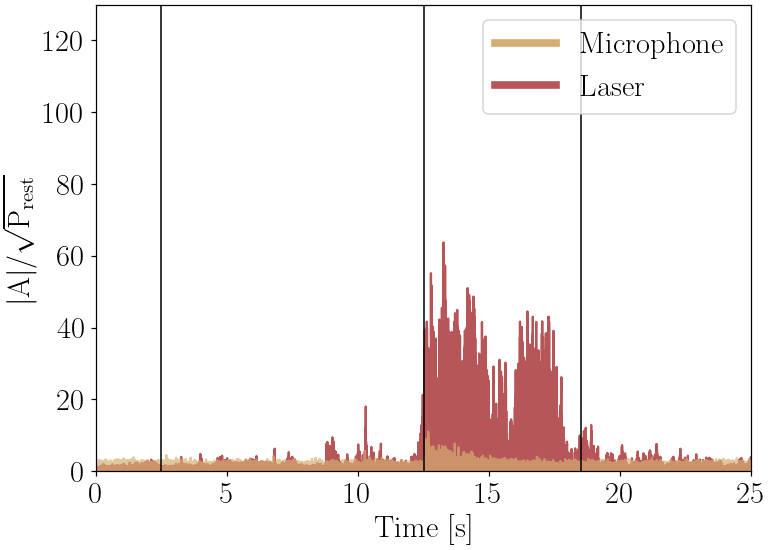

12191
['fs 3700', 'frames_per_buffer None', 'samples_per_frame 50', 'refresh_rate_hz None']
Original data shape: (609500,)
Downsampled data shape: (609500,)
fs: 20176.97741661595
MIC rest_power: 11231982.678924177 ; slip_power: 16617040.230501177 ; sensitivity: 1.2163221711086556
1040
['fs 3700', 'frames_per_buffer None', 'samples_per_frame 100', 'refresh_rate_hz None']
Original data shape: (103900,)
Downsampled data shape: (103900,)
fs: 3634.801838754943
LASER rest_power: 0.00015332728747203438 ; slip_power: 0.025574755196992073 ; sensitivity: 12.915047754629954
-------------- Laser is 10.61811423108248 times more sensitive than mic


In [14]:
%matplotlib notebook

time_axis_offset = 1.5
downsampling = 1
fig = plt.figure(figsize=(7, 5), constrained_layout=True)
data_directory = os.path.join(os.getcwd(), "cable")

laser_data, laser_time_axis, laser_rest_power, mic_data, mic_time_axis, mic_rest_power = parse_sensor_data(
    data_directory=data_directory, mic_file_name='cable_mic4.csv', laser_file_name='cable_laser4.csv', 
    downsampling=downsampling, time_axis_offset=time_axis_offset, 
    mic_signal_range=(277000, 403500), laser_signal_range=(45500, 67200),
    mic_rest_range=(0, int(6e4)), laser_rest_range=(70000, -1))



plt.axvline(-10, linewidth=5, color=mic_color)
plt.axvline(-10, linewidth=5, color=laser_color)

plt.plot(laser_time_axis, abs(laser_data/np.sqrt(laser_rest_power)), alpha=1, color=laser_color)
plt.plot(mic_time_axis[::downsampling], abs(mic_data/np.sqrt(mic_rest_power)), alpha=0.7, color=mic_color)
#plt.plot(20*np.log10(abs(laser_data/np.sqrt(laser_rest_power))), alpha=1, color=laser_color)
#plt.plot(mic_time_axis[::downsampling], 20*np.log10(abs(mic_data/np.sqrt(mic_rest_power))), alpha=0.7, color=mic_color)

plt.axvline(4-time_axis_offset, linewidth=1, color='black')
plt.axvline(14-time_axis_offset, linewidth=1, color='black')
plt.axvline(20-time_axis_offset, linewidth=1, color='black')

plt.xlim([0, 25])
plt.ylim([0, 130])
plt.xlabel('Time [s]')
plt.ylabel('$|$A$|$/$\sqrt{\mathrm{P}_{\mathrm{rest}}}$')
plt.legend(["Microphone", "Laser"])
plt.show()


#plt.savefig('cable_plot.svg')

## Cable fast

10300
['fs 3700', 'frames_per_buffer None', 'samples_per_frame 50', 'refresh_rate_hz None']
Original data shape: (514950,)
Downsampled data shape: (514950,)
fs: 19558.179973768227
MIC rest_power: 34893595.5225632 ; slip_power: 856514701.0053582 ; sensitivity: 4.954439727989389
895
['fs 3700', 'frames_per_buffer None', 'samples_per_frame 100', 'refresh_rate_hz None']
Original data shape: (89400,)
Downsampled data shape: (89400,)
fs: 3634.894006653401
LASER rest_power: 3.0484236019802957e-05 ; slip_power: 0.033361704796552656 ; sensitivity: 33.0815964740374
-------------- Laser is 6.677161957818907 times more sensitive than mic


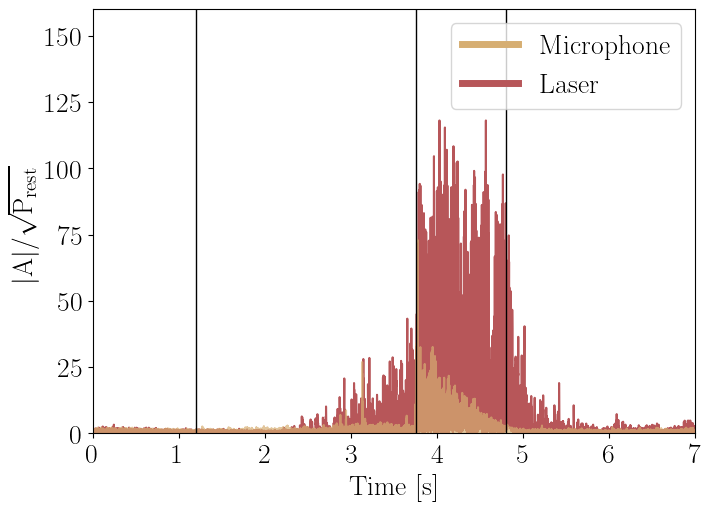

In [7]:
%matplotlib inline

time_axis_offset = 8
fig = plt.figure(figsize=(7, 5), constrained_layout=True)

downsampling = 1
data_directory = os.path.join(os.getcwd(), "cable")

laser_data, laser_time_axis, laser_rest_power, mic_data, mic_time_axis, mic_rest_power = parse_sensor_data(
    data_directory=data_directory, mic_file_name='cable_mic_fast2.csv', laser_file_name='cable_laser_fast2.csv', 
    downsampling=downsampling, time_axis_offset=time_axis_offset, 
    mic_signal_range=(228000, 256000), laser_signal_range=(36000, 41000),
    mic_rest_range=(0, int(1e5)), laser_rest_range=(50000, -1))

plt.axvline(-10, linewidth=5, color=mic_color)
plt.axvline(-10, linewidth=5, color=laser_color)

plt.plot(laser_time_axis[::downsampling], abs(laser_data/np.sqrt(laser_rest_power)), alpha=1, color=laser_color)
plt.plot(mic_time_axis[::downsampling], abs(mic_data/np.sqrt(mic_rest_power)), alpha=0.7, color=mic_color)
#plt.plot(20*np.log10(abs(laser_data/np.sqrt(laser_rest_power))), alpha=1, color=laser_color)
#plt.plot(20*np.log10(abs(mic_data/np.sqrt(mic_rest_power))), alpha=0.7, color=mic_color)

#plt.axvline(9-time_axis_offset, linewidth=1, color='black')
#plt.axvline(11-time_axis_offset, linewidth=1, color='black')
#plt.axvline(13-time_axis_offset, linewidth=1, color='black')
plt.axvline(10.2-1-time_axis_offset, linewidth=1, color='black')
plt.axvline(12.75-1-time_axis_offset, linewidth=1, color='black')
plt.axvline(13.8-1-time_axis_offset, linewidth=1, color='black')

plt.xlim([0, 7])
plt.ylim([0, 160])
plt.xlabel('Time [s]')
plt.ylabel('$|$A$|$/$\sqrt{\mathrm{P}_{\mathrm{rest}}}$')
plt.legend(["Microphone", "Laser"])
plt.show()


#plt.savefig('cable_plot_fast.svg')

# Box

## Box slow

<IPython.core.display.Javascript object>


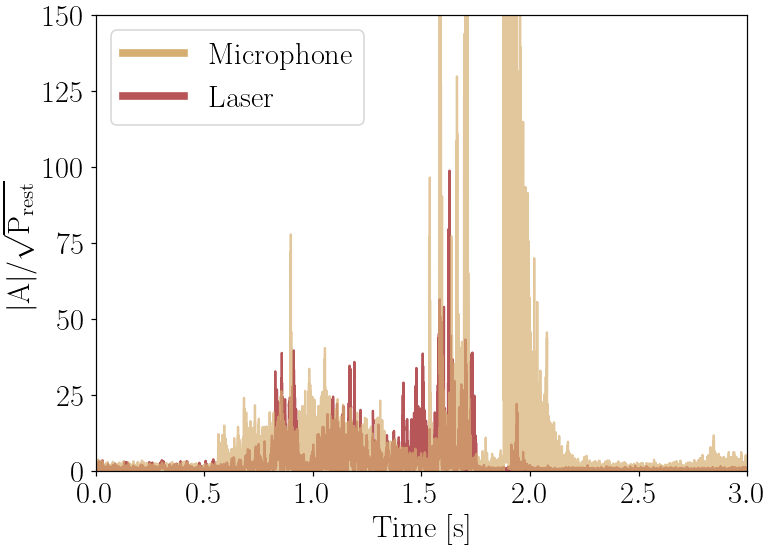

7991
['fs 3700', 'frames_per_buffer None', 'samples_per_frame 50', 'refresh_rate_hz None']
Original data shape: (399500,)
Downsampled data shape: (399500,)
fs: 19586.063861059847
MIC rest_power: 5438381.422269835 ; slip_power: 2116644251.1687477 ; sensitivity: 19.728274580104408
680
['fs 3700', 'frames_per_buffer None', 'samples_per_frame 100', 'refresh_rate_hz None']
Original data shape: (67900,)
Downsampled data shape: (67900,)
fs: 3634.7625694398907
LASER rest_power: 0.00013597954892449906 ; slip_power: 0.01777036173814008 ; sensitivity: 11.431713617636744
-------------- Laser is 0.5794583591798449 times more sensitive than mic


In [10]:
%matplotlib notebook

time_axis_offset = 10
fig = plt.figure(figsize=(7, 5), constrained_layout=True)
downsampling = 1
data_directory = os.path.join(os.getcwd(), "box")


laser_data, laser_time_axis, laser_rest_power, mic_data, mic_time_axis, mic_rest_power = parse_sensor_data(
    data_directory=data_directory, mic_file_name='box_mic.csv', laser_file_name='box_laser.csv', 
    downsampling=downsampling, time_axis_offset=time_axis_offset, 
    mic_signal_range=(213000, 230000), laser_signal_range=(33700, 36850),
    mic_rest_range=(10000, int(1e5)), laser_rest_range=(0, 30000))


plt.axvline(-10, linewidth=5, color=mic_color)
plt.axvline(-10, linewidth=5, color=laser_color)
plt.plot(laser_time_axis, abs(laser_data/np.sqrt(laser_rest_power)), alpha=1, color=laser_color)
plt.plot(mic_time_axis, abs(mic_data/np.sqrt(mic_rest_power)), alpha=0.7, color=mic_color)
#plt.plot(laser_data/np.sqrt(laser_rest_power), alpha=1, color=laser_color)
#plt.plot(mic_data/np.sqrt(mic_rest_power), alpha=0.7, color=mic_color)

'''plt.axvline(laser_time_axis[laser_slip_range[0]], linewidth=1, color='black')
plt.axvline(laser_time_axis[laser_slip_range[1]], linewidth=1, color='black')
plt.axvline(mic_time_axis[slip_range[0]], linewidth=1, color='black')
plt.axvline(mic_time_axis[slip_range[1]], linewidth=1, color='black')'''

plt.xlim([0, 3])
plt.ylim([0, 150])
plt.xlabel('Time [s]')
plt.ylabel('$|$A$|$/$\sqrt{\mathrm{P}_{\mathrm{rest}}}$')
plt.legend(["Microphone", "Laser"])
plt.show()

#plt.savefig('box_plot.svg')

## Box fast

<IPython.core.display.Javascript object>


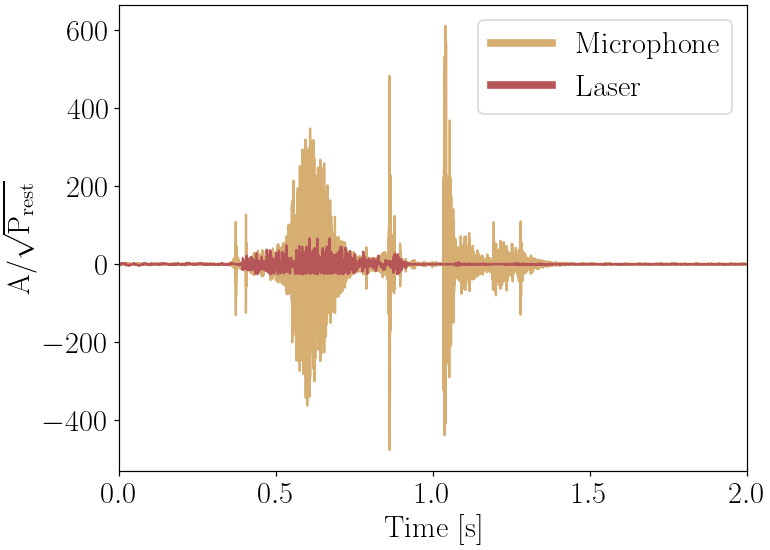

7874
['fs 3700', 'frames_per_buffer None', 'samples_per_frame 50', 'refresh_rate_hz None']
Original data shape: (393650,)
Downsampled data shape: (393650,)
fs: 19425.99335593029
MIC rest_power: 27187791.972420506 ; slip_power: 97309689140.71974 ; sensitivity: 59.82615247062203
675
['fs 3700', 'frames_per_buffer None', 'samples_per_frame 100', 'refresh_rate_hz None']
Original data shape: (67400,)
Downsampled data shape: (67400,)
fs: 3635.051409280847
LASER rest_power: 0.0005285597505215578 ; slip_power: 0.12726718584948685 ; sensitivity: 15.51712205066497
-------------- Laser is 0.2593702153633353 times more sensitive than mic
-------------- Mic is 3.8554928082207254 times more sensitive than laser


In [15]:
%matplotlib notebook

time_axis_offset = 8.5
fig = plt.figure(figsize=(7, 5), constrained_layout=True)
downsampling = 1
data_directory = os.path.join(os.getcwd(), "box")

file_name = 'box_fast_mic.csv'

data, header, timestamps, time_axis = read_data(data_directory, file_name, downsampling)
mic_time_axis = np.array(time_axis) - time_axis_offset
mic_start_timestamp = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
time1 = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
time2 = datetime.strptime(timestamps[-1], '%Y-%m-%d %H:%M:%S.%f')
time_difference = (time2 - time1).total_seconds()
fs = len(data)/time_difference / downsampling
print(f'fs: {fs}')

mic_data = np.clip(data - np.mean(data), -40000000, 40000000)
num_samples = int(3*fs)
mic_rest_power = np.sum((np.array(mic_data[:num_samples]) - np.mean(mic_data[:num_samples]))**2)/num_samples
slip_range = [173500, 181500]
mic_slip_power = np.sum((np.array(mic_data[slip_range[0]:slip_range[1]]) - np.mean(mic_data[slip_range[0]:slip_range[1]]))**2)/(slip_range[1] - slip_range[0])
power = np.sum(np.array(mic_data)**2)/len(list(mic_data))
mic_sensitivity = np.sqrt(mic_slip_power/mic_rest_power)
print(f'MIC rest_power: {mic_rest_power} ; slip_power: {mic_slip_power} ; sensitivity: {mic_sensitivity}')






file_name = 'box_fast_laser.csv'

data, header, timestamps, time_axis = read_data(data_directory, file_name, downsampling)
laser_start_timestamp = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
laser_time_axis = np.array(time_axis) + (laser_start_timestamp - mic_start_timestamp).total_seconds() - time_axis_offset
time1 = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
time2 = datetime.strptime(timestamps[-1], '%Y-%m-%d %H:%M:%S.%f')
time_difference = (time2 - time1).total_seconds()
fs = len(data)/time_difference / downsampling
print(f'fs: {fs}')

laser_data = data - np.mean(data)
num_samples = int(3*fs)
laser_rest_power = np.sum((np.array(laser_data[:num_samples]) - np.mean(laser_data[:num_samples]))**2)/num_samples
laser_slip_range = [26750, 28350]
laser_slip_power = np.sum((np.array(laser_data[laser_slip_range[0]:laser_slip_range[1]]) - np.mean(laser_data[laser_slip_range[0]:laser_slip_range[1]]))**2)/(laser_slip_range[1] - laser_slip_range[0])
power = np.sum(np.array(laser_data)**2)/len(list(laser_data))
laser_sensitivity = np.sqrt(laser_slip_power/laser_rest_power)
print(f'LASER rest_power: {laser_rest_power} ; slip_power: {laser_slip_power} ; sensitivity: {laser_sensitivity}')

print(f'-------------- Laser is {laser_sensitivity/mic_sensitivity} times more sensitive than mic')
print(f'-------------- Mic is {mic_sensitivity/laser_sensitivity} times more sensitive than laser')



plt.axvline(-10, linewidth=5, color=mic_color)
plt.axvline(-10, linewidth=5, color=laser_color)
plt.plot(mic_time_axis, mic_data/np.sqrt(mic_rest_power), alpha=1, color=mic_color)
plt.plot(laser_time_axis, laser_data/np.sqrt(laser_rest_power), alpha=1, color=laser_color)

'''plt.axvline(laser_time_axis[laser_slip_range[0]], linewidth=1, color='black')
plt.axvline(laser_time_axis[laser_slip_range[1]], linewidth=1, color='black')
plt.axvline(mic_time_axis[slip_range[0]], linewidth=1, color='black')
plt.axvline(mic_time_axis[slip_range[1]], linewidth=1, color='black')'''

plt.xlim([0, 2])
plt.xlabel('Time [s]')
plt.ylabel('$|$A$|$/$\sqrt{\mathrm{P}_{\mathrm{rest}}}$')
#plt.ylim([-400, 400])
plt.legend(["Microphone", "Laser"])
plt.show()

#plt.savefig('box_plot_fast.svg')

# Pencil

## Pencil no external noise

<IPython.core.display.Javascript object>


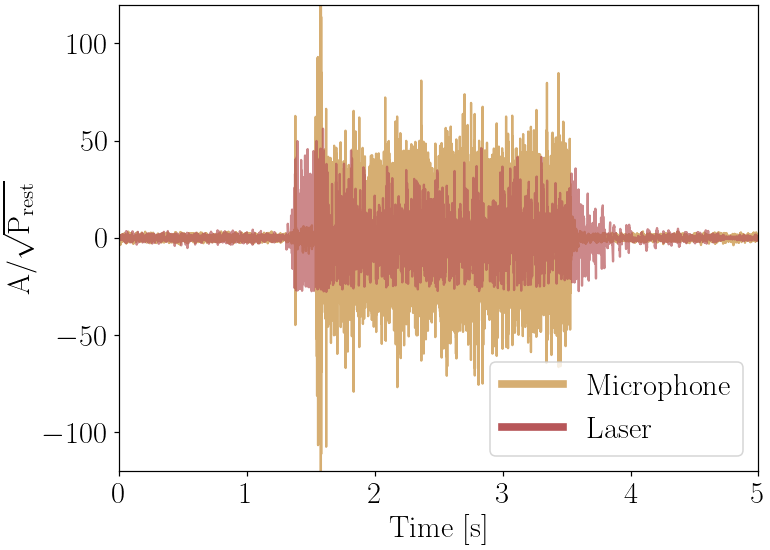

4688
['fs 3700', 'frames_per_buffer None', 'samples_per_frame 50', 'refresh_rate_hz None']
Original data shape: (234350,)
Downsampled data shape: (234350,)
fs: 20260.3544157155
MIC rest_power: 9443349.78079411 ; slip_power: 2559122172.240484 ; sensitivity: 16.461995236115513
364
['fs 3700', 'frames_per_buffer None', 'samples_per_frame 100', 'refresh_rate_hz None']
Original data shape: (36300,)
Downsampled data shape: (36300,)
fs: 3635.2631339653553
LASER rest_power: 0.0004931715228012033 ; slip_power: 0.05871437397426368 ; sensitivity: 10.911217722017685
-------------- Laser is 0.6628125913971757 times more sensitive than mic
-------------- Mic is 1.5087220927593576 times more sensitive than laser


In [16]:
%matplotlib notebook


time_axis_offset = 2
fig = plt.figure(figsize=(7, 5), constrained_layout=True)
downsampling = 1
data_directory = os.path.join(os.getcwd(), "pencil")

file_name = 'pencil_mic.csv'

data, header, timestamps, time_axis = read_data(data_directory, file_name, downsampling)
mic_time_axis = np.array(time_axis) - time_axis_offset
mic_start_timestamp = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
time1 = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
time2 = datetime.strptime(timestamps[-1], '%Y-%m-%d %H:%M:%S.%f')
time_difference = (time2 - time1).total_seconds()
fs = len(data)/time_difference / downsampling
print(f'fs: {fs}')

mic_data = np.clip(data - np.mean(data), -40000000, 40000000)
num_samples = int(fs)
mic_rest_power = np.sum((np.array(mic_data[:num_samples]) - np.mean(mic_data[:num_samples]))**2)/num_samples
slip_range = [77000, 106000]
mic_slip_power = np.sum((np.array(mic_data[slip_range[0]:slip_range[1]]) - np.mean(mic_data[slip_range[0]:slip_range[1]]))**2)/(slip_range[1] - slip_range[0])
power = np.sum(np.array(mic_data)**2)/len(list(mic_data))
mic_sensitivity = np.sqrt(mic_slip_power/mic_rest_power)
print(f'MIC rest_power: {mic_rest_power} ; slip_power: {mic_slip_power} ; sensitivity: {mic_sensitivity}')





file_name = 'pencil_laser.csv'

data, header, timestamps, time_axis = read_data(data_directory, file_name, downsampling)
laser_start_timestamp = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
laser_time_axis = np.array(time_axis) + (laser_start_timestamp - mic_start_timestamp).total_seconds() - time_axis_offset
time1 = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
time2 = datetime.strptime(timestamps[-1], '%Y-%m-%d %H:%M:%S.%f')
time_difference = (time2 - time1).total_seconds()
fs = len(data)/time_difference / downsampling
print(f'fs: {fs}')

laser_data = data - np.mean(data)
num_samples = int(fs)
laser_rest_power = np.sum((np.array(laser_data[:num_samples]) - np.mean(laser_data[:num_samples]))**2)/num_samples
laser_slip_range = [9000, 14000]
laser_slip_power = np.sum((np.array(laser_data[laser_slip_range[0]:laser_slip_range[1]]) - np.mean(laser_data[laser_slip_range[0]:laser_slip_range[1]]))**2)/(laser_slip_range[1] - laser_slip_range[0])
power = np.sum(np.array(laser_data)**2)/len(list(laser_data))
laser_sensitivity = np.sqrt(laser_slip_power/laser_rest_power)
print(f'LASER rest_power: {laser_rest_power} ; slip_power: {laser_slip_power} ; sensitivity: {laser_sensitivity}')

print(f'-------------- Laser is {laser_sensitivity/mic_sensitivity} times more sensitive than mic')
print(f'-------------- Mic is {mic_sensitivity/laser_sensitivity} times more sensitive than laser')



plt.axvline(-10, linewidth=5, color=mic_color)
plt.axvline(-10, linewidth=5, color=laser_color)
plt.plot(mic_time_axis, mic_data/np.sqrt(mic_rest_power), alpha=1, color=mic_color)
plt.plot(laser_time_axis, laser_data/np.sqrt(laser_rest_power), alpha=0.7, color=laser_color)

'''plt.axvline(laser_time_axis[laser_slip_range[0]], linewidth=1, color='black')
plt.axvline(laser_time_axis[laser_slip_range[1]], linewidth=1, color='black')
plt.axvline(mic_time_axis[slip_range[0]], linewidth=1, color='black')
plt.axvline(mic_time_axis[slip_range[1]], linewidth=1, color='black')'''

plt.xlim([0, 5])
plt.xlabel('Time [s]')
plt.ylabel('$|$A$|$/$\sqrt{\mathrm{P}_{\mathrm{rest}}}$')
plt.ylim([-120, 120])
plt.legend(["Microphone", "Laser"])
plt.show()

#plt.savefig('pencil_plot_noNoise.svg')

## Pencil with external noise

<IPython.core.display.Javascript object>


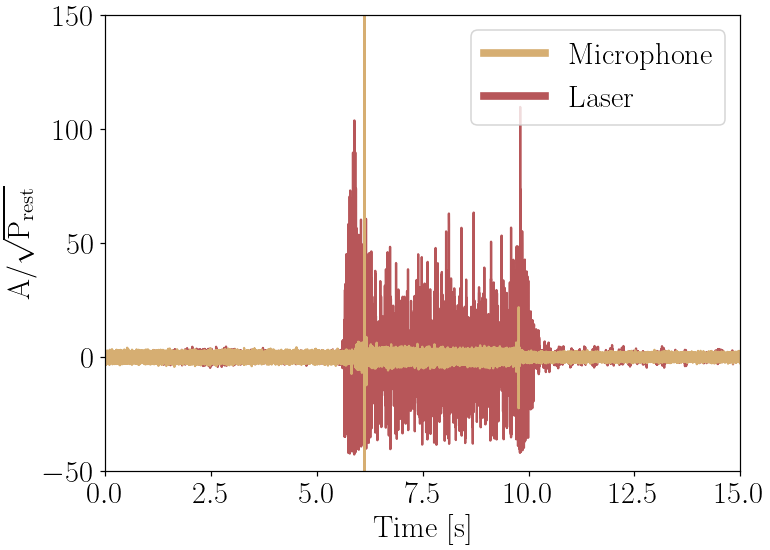

7070
['fs 3700', 'frames_per_buffer None', 'samples_per_frame 50', 'refresh_rate_hz None']
Original data shape: (353450,)
Downsampled data shape: (353450,)
fs: 19685.400071991367
MIC rest_power: 761648621.3632433 ; slip_power: 1312708828.560378 ; sensitivity: 1.3128251043771824
590
['fs 3700', 'frames_per_buffer None', 'samples_per_frame 100', 'refresh_rate_hz None']
Original data shape: (58900,)
Downsampled data shape: (58900,)
fs: 3635.278270985122
LASER rest_power: 0.00021383490890552502 ; slip_power: 0.028768284392307608 ; sensitivity: 11.598923356115591
-------------- Laser is 8.835086499673723 times more sensitive than mic
-------------- Mic is 0.11318508313834048 times more sensitive than laser


In [6]:
%matplotlib notebook

time_axis_offset = 2
fig = plt.figure(figsize=(7, 5), constrained_layout=True)
downsampling = 1
data_directory = os.path.join(os.getcwd(), "pencil")

file_name = 'pencil_mic_noise.csv'

data, header, timestamps, time_axis = read_data(data_directory, file_name, downsampling)
mic_time_axis = np.array(time_axis) - time_axis_offset
mic_start_timestamp = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
time1 = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
time2 = datetime.strptime(timestamps[-1], '%Y-%m-%d %H:%M:%S.%f')
time_difference = (time2 - time1).total_seconds()
fs = len(data)/time_difference / downsampling
print(f'fs: {fs}')

mic_data = data - np.mean(data)
num_samples = int(4*fs)
mic_rest_power = np.sum((np.array(mic_data[:num_samples]) - np.mean(mic_data[:num_samples]))**2)/num_samples
slip_range = [170000, 220000]
mic_slip_power = np.sum((np.array(mic_data[slip_range[0]:slip_range[1]]) - np.mean(mic_data[slip_range[0]:slip_range[1]]))**2)/(slip_range[1] - slip_range[0])
power = np.sum(np.array(mic_data)**2)/len(list(mic_data))
mic_sensitivity = np.sqrt(mic_slip_power/mic_rest_power)
print(f'MIC rest_power: {mic_rest_power} ; slip_power: {mic_slip_power} ; sensitivity: {mic_sensitivity}')





file_name = 'pencil_laser_noise.csv'

data, header, timestamps, time_axis = read_data(data_directory, file_name, downsampling)
laser_start_timestamp = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
laser_time_axis = np.array(time_axis) + (laser_start_timestamp - mic_start_timestamp).total_seconds() - time_axis_offset
time1 = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
time2 = datetime.strptime(timestamps[-1], '%Y-%m-%d %H:%M:%S.%f')
time_difference = (time2 - time1).total_seconds()
fs = len(data)/time_difference / downsampling
print(f'fs: {fs}')

laser_data = data - np.mean(data)
num_samples = int(4*fs)
laser_rest_power = np.sum((np.array(laser_data[:num_samples]) - np.mean(laser_data[:num_samples]))**2)/num_samples
slip_range = [25000, 36000]
laser_slip_power = np.sum((np.array(laser_data[slip_range[0]:slip_range[1]]) - np.mean(laser_data[slip_range[0]:slip_range[1]]))**2)/(slip_range[1] - slip_range[0])
power = np.sum(np.array(laser_data)**2)/len(list(laser_data))
laser_sensitivity = np.sqrt(laser_slip_power/laser_rest_power)
print(f'LASER rest_power: {laser_rest_power} ; slip_power: {laser_slip_power} ; sensitivity: {laser_sensitivity}')

print(f'-------------- Laser is {laser_sensitivity/mic_sensitivity} times more sensitive than mic')
print(f'-------------- Mic is {mic_sensitivity/laser_sensitivity} times more sensitive than laser')



plt.axvline(-10, linewidth=5, color=mic_color)
plt.axvline(-10, linewidth=5, color=laser_color)
plt.plot(laser_time_axis, laser_data/np.sqrt(laser_rest_power), alpha=1, color=laser_color)
plt.plot(mic_time_axis, mic_data/np.sqrt(mic_rest_power), alpha=1, color=mic_color)


plt.xlim([0, 15])
plt.ylim([-50, 150])
plt.xlabel('Time [s]')
plt.ylabel('$|$A$|$/$\sqrt{\mathrm{P}_{\mathrm{rest}}}$')
plt.legend(["Microphone", "Laser"])
plt.show()

#plt.savefig('pencil_plot_noise.svg')

### No pencil

<IPython.core.display.Javascript object>


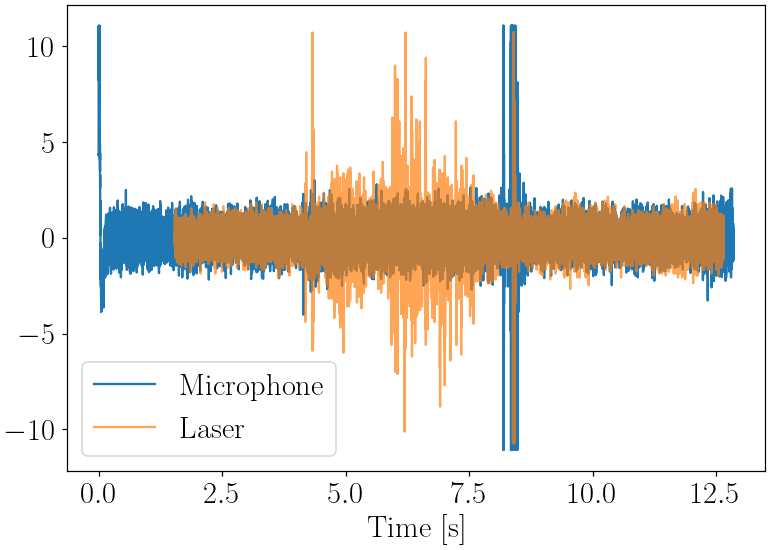

5051
['fs 3700', 'frames_per_buffer None', 'samples_per_frame 50', 'refresh_rate_hz None']
Original data shape: (252500,)
Downsampled data shape: (252500,)
fs: 19649.599011994815
rest_power: 63311643.83559764
405
['fs 3700', 'frames_per_buffer None', 'samples_per_frame 100', 'refresh_rate_hz None']
Original data shape: (40400,)
Downsampled data shape: (40400,)
fs: 3635.7778539731225
rest_power: 4.167413543220185e-05


In [7]:
# 
#
#        Same movement, no pencil in hand, to characterise motor noise
#
#

%matplotlib notebook

fig = plt.figure(figsize=(7, 5), constrained_layout=True)
downsampling = 1
data_directory = os.path.join(os.getcwd(), "pencil")


file_name = 'pencil_mic_moveOnly.csv'

data, header, timestamps, time_axis = read_data(data_directory, file_name, downsampling)
mic_start_timestamp = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
time1 = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
time2 = datetime.strptime(timestamps[-1], '%Y-%m-%d %H:%M:%S.%f')
time_difference = (time2 - time1).total_seconds()
fs = len(data)/time_difference / downsampling
print(f'fs: {fs}')

data = np.clip(data - np.mean(data), -50000, 50000)
num_samples = 20000
rest_power = np.sum(np.array(data[0:num_samples])**2)/num_samples
power = np.sum(np.array(data)**2)/len(list(data))
print(f'rest_power: {rest_power}')

#plt.plot(time_axis, abs(data)/np.sqrt(rest_power))
plt.plot(time_axis, data/np.sqrt(power), alpha=1)



file_name = 'pencil_laser_moveOnly.csv'

data, header, timestamps, time_axis = read_data(data_directory, file_name, downsampling)
laser_start_timestamp = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
time_axis = np.array(time_axis) + (laser_start_timestamp - mic_start_timestamp).total_seconds()
time1 = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
time2 = datetime.strptime(timestamps[-1], '%Y-%m-%d %H:%M:%S.%f')
time_difference = (time2 - time1).total_seconds()
fs = len(data)/time_difference / downsampling
print(f'fs: {fs}')

data = np.clip(data - np.mean(data), -0.13, 0.13)
num_samples = 3600
rest_power = np.sum(np.array(data[100:num_samples+100])**2)/num_samples
power = np.sum(np.array(data)**2)/len(list(data))
print(f'rest_power: {rest_power}')

plt.plot(time_axis, data/np.sqrt(power), alpha=0.7)



plt.xlabel('Time [s]')
#plt.ylim([-12, 12])
plt.legend(["Microphone", "Laser"])
plt.show()



## Laser pencil vs no pencil

<IPython.core.display.Javascript object>


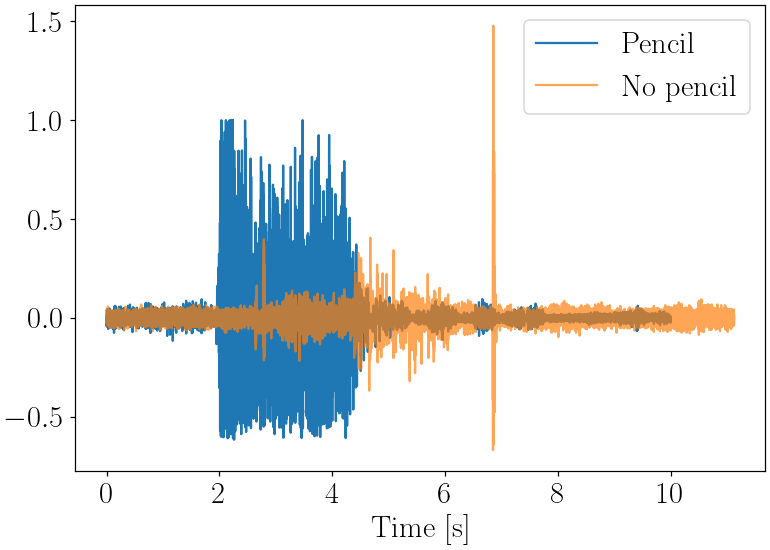

364
['fs 3700', 'frames_per_buffer None', 'samples_per_frame 100', 'refresh_rate_hz None']
Original data shape: (36300,)
Downsampled data shape: (36300,)
fs: 3635.2631339653553
rest_power: 0.000496212350644023
405
['fs 3700', 'frames_per_buffer None', 'samples_per_frame 100', 'refresh_rate_hz None']
Original data shape: (40400,)
Downsampled data shape: (40400,)
fs: 3635.7778539731225
rest_power: 4.167413543220185e-05


In [6]:
# 
#
#        Same movement, no pencil in hand, to characterise motor noise
#
#

%matplotlib notebook


fig = plt.figure(figsize=(7, 5), constrained_layout=True)
downsampling = 1

data_directory = "/home/idlab403/data/LaserMic"
file_name = 'pencil_laser.csv'

data, header, timestamps, time_axis = read_data(data_directory, file_name, downsampling)
mic_start_timestamp = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
time1 = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
time2 = datetime.strptime(timestamps[-1], '%Y-%m-%d %H:%M:%S.%f')
time_difference = (time2 - time1).total_seconds()
fs = len(data)/time_difference / downsampling
print(f'fs: {fs}')

data = np.clip(data - np.mean(data), -1, 1)
num_samples = 3600
rest_power = np.sum(np.array(data[0:num_samples])**2)/num_samples
power = np.sum(np.array(data)**2)/len(list(data))
print(f'rest_power: {rest_power}')

#plt.plot(time_axis, abs(data)/np.sqrt(rest_power))
plt.plot(time_axis, data, alpha=1)





downsampling = 1

data_directory = "/home/idlab403/data/LaserMic"
file_name = 'pencil_laser_moveOnly.csv'

data, header, timestamps, time_axis = read_data(data_directory, file_name, downsampling)
laser_start_timestamp = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
time1 = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
time2 = datetime.strptime(timestamps[-1], '%Y-%m-%d %H:%M:%S.%f')
time_difference = (time2 - time1).total_seconds()
fs = len(data)/time_difference / downsampling
print(f'fs: {fs}')

data = np.clip(data - np.mean(data), -1, 1)
num_samples = 3600
rest_power = np.sum(np.array(data[100:num_samples+100])**2)/num_samples
power = np.sum(np.array(data)**2)/len(list(data))
print(f'rest_power: {rest_power}')

plt.plot(time_axis, 3*data, alpha=0.7)



plt.xlabel('Time [s]')
#plt.ylim([-12, 12])
plt.legend(["Pencil", "No pencil"])
plt.show()

